# Agentic playground with NeMo Retriever

End-to-end document ingestion and retrieval-augmented generation (RAG) using **NVIDIA NIM APIs** — no local GPU required.

**Workflow:**
1. Configure environment and initialise Ray
2. Ingest a PDF via NVIDIA extraction and embedding NIMs → LanceDB
3. Run a simple single-shot RAG query
4. Explore the vector database contents
5. Run a ReAct agent that iteratively queries the knowledge base

## 1. Configuration

Set the environment variables before importing other modules. Replace `NVIDIA_API_KEY` with your key from [build.nvidia.com](https://build.nvidia.com).

In [58]:
import os

# Scratch directory for Ray temporary files — adjust to a local path with sufficient space
os.environ["RAY_TMPDIR"] = "/raid/mwason/tmp"

from dotenv import load_dotenv
load_dotenv()  # reads .env in the working directory

# # NVIDIA NIM API key — obtain from https://build.nvidia.com
# os.environ["NVIDIA_API_KEY"] = "your-api-key-here"

# ── Shared model config ──────────────────────────────────────────────
MODEL_NAME   = "nvidia/nemotron-3-nano-30b-a3b"
API_BASE_URL = "https://integrate.api.nvidia.com/v1"

# ── Shared queries — run through both one-shot RAG and ReAct agent ───
QUERIES = [
    "Which animal is doing something unusual in a location that could also plausibly contain a gadget from the cost chart?",
    "Which animals mentioned in the document can be of similar tones as the most popular colors of trucks and convertibles?",
    # "Reconstruct the full training and inference pipeline, highlighting where the procedures diverge and why.",
    # "Compare the relative impact of normalization, overlapping pooling, and multi-GPU training on error reduction, and explain why their gains differ.",
    # "Why does removing even a small convolutional layer degrade performance significantly despite it containing a small fraction of parameters?",
    # "How do dropout and data augmentation complement each other in reducing overfitting, and what limitations remain?",
    # "How does the specialization of GPUs observed in the learned filters relate to the connectivity constraints in the architecture?",
    
    # Add more queries here
]


## 2. Initialise Ray

NeMo Retriever uses Ray for distributed batch processing. The dashboard is disabled here for a lighter footprint.

In [59]:
import ray

ray.init(include_dashboard=False)

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:3                                                                                    │
│                                                                                                  │
│   1 import ray                                                                                   │
│   2                                                                                              │
│ ❱ 3 ray.init(include_dashboard=False)                                                            │
│   4                                                                                              │
│                                                                                                  │
│ /raid/mwason/retriever/lib/python3.12/site-packages/ray/_private/client_mode_hook.py:104 in      │
│ wrapper                                                                                          │
│                                                                                                  │
│   101 │   │   │   # we only convert init function if RAY_CLIENT_MODE=1                           │
│   102 │   │   │   if func.__name__ != "init" or is_client_mode_enabled_by_default:               │
│   103 │   │   │   │   return getattr(ray, func.__name__)(*args, **kwargs)                        │
│ ❱ 104 │   │   return func(*args, **kwargs)                                                       │
│   105 │                                                                                          │
│   106 │   return wrapper                                                                         │
│   107                                                                                            │
│                                                                                                  │
│ /raid/mwason/retriever/lib/python3.12/site-packages/ray/_private/worker.py:1835 in init          │
│                                                                                                  │
│   1832 │   │   │   node_id = global_worker.core_worker.get_current_node_id()                     │
│   1833 │   │   │   return RayContext(dict(_global_node.address_info, node_id=node_id.hex()))     │
│   1834 │   │   else:                                                                             │
│ ❱ 1835 │   │   │   raise RuntimeError(                                                           │
│   1836 │   │   │   │   "Maybe you called ray.init twice by accident? "                           │
│   1837 │   │   │   │   "This error can be suppressed by passing in "                             │
│   1838 │   │   │   │   "'ignore_reinit_error=True' or by calling "                               │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
RuntimeError: Maybe you called ray.init twice by accident? This error can be suppressed by passing in 
'ignore_reinit_error=True' or by calling 'ray.shutdown()' prior to 'ray.init()'.

## 3. Ingest Documents

Build the NeMo Retriever ingestion pipeline. Each stage calls a remote NVIDIA NIM:

| Stage | NIM | Purpose |
|-------|-----|---------|
| Extract | `nemotron-page-elements-v3`, `nemotron-graphic-elements-v1`, `nemoretriever-ocr-v1`, `nemotron-table-structure-v1` | Parse layout, graphics, OCR, tables |
| Embed  | `nvidia/llama-nemotron-embed-1b-v2` | Produce text embeddings |
| Upload | — | Write chunks + vectors to LanceDB |

In [60]:
from pathlib import Path
from nemo_retriever import create_ingestor

# Update this path to point at the PDF you want to ingest
PDF_PATH = str(Path("/home/nfs/mwason/nemo/NeMo-Retriever/data/multimodal_test.pdf"))

ingestor = (
    create_ingestor(run_mode="batch")
    .files([PDF_PATH])
    .extract(
        page_elements_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-page-elements-v3",
        graphic_elements_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-graphic-elements-v1",
        ocr_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemoretriever-ocr-v1",
        table_structure_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-table-structure-v1",
    )
    .embed(
        embed_invoke_url="https://integrate.api.nvidia.com/v1/embeddings",
        model_name="nvidia/llama-nemotron-embed-1b-v2",
        embed_modality="text",
    )
    .vdb_upload()
)

2026-03-31 09:21:14,846	INFO worker.py:1831 -- Calling ray.init() again after it has already been called.


### Run Ingestion

Execute the pipeline. This may take a few minutes on the first run.

In [61]:
ray_dataset = ingestor.ingest()
chunks = ray_dataset.get_dataset().take_all()

print(f"Total chunks: {len(chunks)}")
print(f"Chunk fields: {list(chunks[0].keys())}")

2026-03-31 09:21:16,329	INFO logging.py:392 -- Registered dataset logger for dataset dataset_38_0
2026-03-31 09:21:16,336	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_38_0. Full logs are in /raid/mwason/tmp/ray/session_2026-03-30_21-46-51_501029_2381750/logs/ray-data
2026-03-31 09:21:16,336	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_38_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadBinary] -> ActorPoolMapOperator[MapBatches(DocToPdfConversionActor)] -> TaskPoolMapOperator[MapBatches(PDFSplitActor)] -> TaskPoolMapOperator[MapBatches(PDFExtractionActor)] -> TaskPoolMapOperator[StreamingRepartition[num_rows_per_block=32]] -> ActorPoolMapOperator[MapBatches(PageElementDetectionActor)] -> ActorPoolMapOperator[MapBatches(GraphicElementsActor)] -> ActorPoolMapOperator[MapBatches(TableStructureActor)] -> ActorPoolMapOperator[MapBatches(OCRActor)] -> TaskPoolMapOperator[StreamingRepartition[num_rows_per_block=256]] -> ActorPoolMapOperato

Total chunks: 8
Chunk fields: ['path', 'page_number', 'source_id', 'text', 'page_image', 'images', 'tables', 'charts', 'infographics', 'metadata', 'page_elements_v3', 'page_elements_v3_num_detections', 'page_elements_v3_counts_by_label', 'chart', 'graphic_elements_ocr_v1', 'table', 'table_structure_ocr_v1', 'infographic', 'ocr_v1', '_content_type', 'text_embeddings_1b_v2', '_contains_embeddings', 'text_embeddings_1b_v2_dim', 'text_embeddings_1b_v2_has_embedding']


### Inspect Chunk Content

Print the raw text extracted from every chunk.

In [62]:
for i, chunk in enumerate(chunks):
    print(f"--- Chunk {i} ---")
    print(chunk["text"])
    print()

--- Chunk 0 ---
TestingDocument
A sample document with headings and placeholder text
Introduction
This is a placeholder document that can be used for any purpose. It contains some 
headings and some placeholder text to fill the space. The text is not important and contains 
no real value, but it is useful for testing. Below, we will have some simple tables and charts 
that we can use to confirm Ingest is working as expected.
Table 1
This table describes some animals, and some activities they might be doing in specific 
locations.
Animal Activity Place
Gira@e Driving a car At the beach
Lion Putting on sunscreen At the park
Cat Jumping onto a laptop In a home o@ice
Dog Chasing a squirrel In the front yard
Chart 1
This chart shows some gadgets, and some very fictitious costs.

--- Chunk 1 ---
| lable 1 |
| This table describes some animals, and some activities they might be doing in specific |
| locations. |
| Animal | Activity | Place |
| Giraffe | Driving a car | At the beach |
| Lion |

## 4. Retriever & LLM Setup

Initialise the `Retriever` against the LanceDB backend and the shared OpenAI-compatible
client. Both the one-shot RAG helper and the ReAct agent defined later use these objects.


In [63]:
from nemo_retriever.retriever import Retriever
from openai import OpenAI

retriever = Retriever(
    lancedb_uri="lancedb",
    lancedb_table="nv-ingest",
    embedder="nvidia/llama-3.2-nv-embedqa-1b-v2",
    top_k=5,
    reranker=False,
)

client = OpenAI(
    base_url=API_BASE_URL,
    api_key=os.environ.get("NVIDIA_API_KEY"),
)


## 5. LanceDB Exploration

Directly inspect the LanceDB vector store — useful for debugging ingestion results, reviewing the schema, and visualising the embedding space.

### Schema & Data

In [64]:
import lancedb

db = lancedb.connect("lancedb")
table = db.open_table("nv-ingest")

print(table.schema)

vector: fixed_size_list<item: float>[2048]
  child 0, item: float
pdf_page: string
filename: string
pdf_basename: string
page_number: int32
source: string
source_id: string
path: string
text: string
metadata: string


In [65]:
df = table.to_pandas()
print(f"Columns: {list(df.columns)}\n")
print(df.head())

Columns: ['vector', 'pdf_page', 'filename', 'pdf_basename', 'page_number', 'source', 'source_id', 'path', 'text', 'metadata']

                                              vector           pdf_page  \
0  [-0.0009279251, -0.005710602, 0.034454346, 0.0...  multimodal_test_1   
1  [-0.0062065125, 0.035064697, 0.040740967, -0.0...  multimodal_test_1   
2  [0.013954163, 0.01689148, 0.026306152, 0.02578...  multimodal_test_1   
3  [-0.013458252, 0.0067749023, 0.023620605, 0.01...  multimodal_test_2   
4  [0.0023021698, 0.010917664, 0.0289917, 0.01829...  multimodal_test_2   

              filename     pdf_basename  page_number  \
0  multimodal_test.pdf  multimodal_test            1   
1  multimodal_test.pdf  multimodal_test            1   
2  multimodal_test.pdf  multimodal_test            1   
3  multimodal_test.pdf  multimodal_test            2   
4  multimodal_test.pdf  multimodal_test            2   

                                              source  \
0  {"source_id": "/home/nfs/m

In [66]:
for i, row in df.iterrows():
    print(f"--- Chunk {i} ---")
    print(f"Text:       {row['text'][:100]}")
    print(f"Page:       {row['page_number']}")
    print(f"Source:     {row['source']}")
    print(f"Vector dim: {len(row['vector'])}")
    print()

--- Chunk 0 ---
Text:       TestingDocument
A sample document with headings and placeholder text
Introduction
This is a place
Page:       1
Source:     {"source_id": "/home/nfs/mwason/nemo/NeMo-Retriever/data/multimodal_test.pdf"}
Vector dim: 2048

--- Chunk 1 ---
Text:       | lable 1 |
| This table describes some animals, and some activities they might be doing in specific
Page:       1
Source:     {"source_id": "/home/nfs/mwason/nemo/NeMo-Retriever/data/multimodal_test.pdf"}
Vector dim: 2048

--- Chunk 2 ---
Text:       Chart 1 This chart shows some gadgets, and some very fictitious costs. Gadgets and their cost $160.0
Page:       1
Source:     {"source_id": "/home/nfs/mwason/nemo/NeMo-Retriever/data/multimodal_test.pdf"}
Vector dim: 2048

--- Chunk 3 ---
Text:       Section One
This is the first section of the document. It has some more placeholder text to show ho
Page:       2
Source:     {"source_id": "/home/nfs/mwason/nemo/NeMo-Retriever/data/multimodal_test.pdf"}
Vector dim: 20

### Embedding Visualisation (PCA)

Reduce the high-dimensional embedding vectors to 2D with PCA to get an intuitive sense of how chunks cluster in the embedding space.

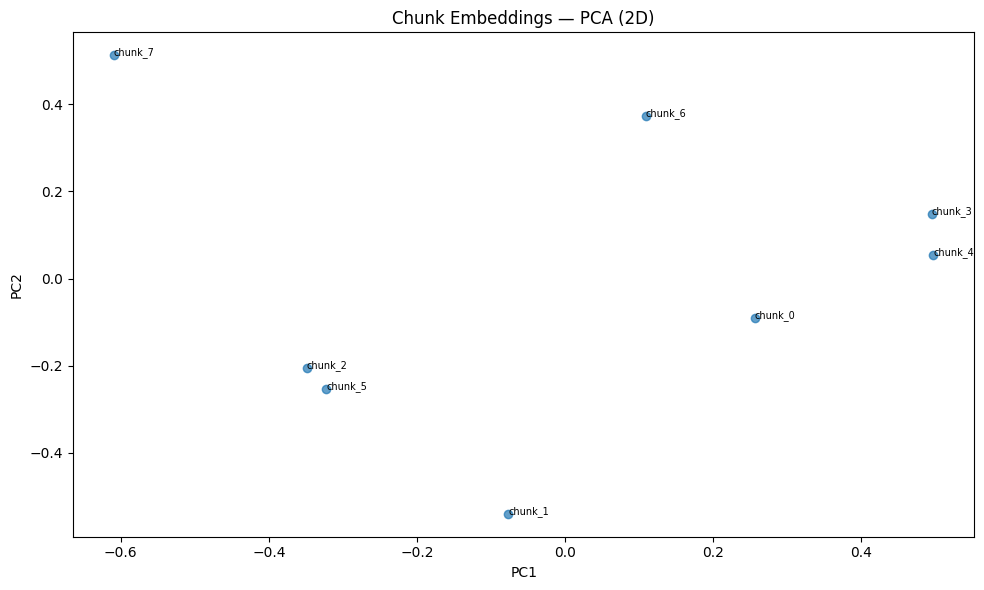

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

vectors = np.stack(df["vector"].values)
reduced = PCA(n_components=2).fit_transform(vectors)

plt.figure(figsize=(10, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.7)
for i in range(len(df)):
    plt.annotate(f"chunk_{i}", reduced[i], fontsize=7)
plt.title("Chunk Embeddings — PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## 6. ReAct Agent Loop

A minimal [ReAct](https://arxiv.org/abs/2210.03629) (Reason + Act) agent that iteratively searches the knowledge base before producing a final answer.

| Tool | Description |
|------|-------------|
| `query_docs` | Semantic search over the ingested vector DB |
| `ingest_pdf` | Ingest a new PDF into the knowledge base at runtime |
| `final_answer` | Return the final answer and terminate the loop |

In [68]:
import json

MAX_ITERATIONS = 8


In [69]:
SYSTEM_PROMPT = """You are a research assistant with access to a document knowledge base.

To answer the user's question:
1. Break the question into sub-questions if needed
2. Search for each sub-question separately using query_docs
3. Use different query phrasings if initial results are insufficient
4. Never repeat the same query twice
5. When you have enough evidence, call final_answer with a complete, grounded response
6. Do not make up information not found in the retrieved documents"""


### Tool Definitions

OpenAI-compatible JSON schemas for the three agent tools, followed by their Python implementations.

In [70]:
TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "query_docs",
            "description": "Search the document knowledge base for relevant text chunks. Call multiple times with different queries to gather more context.",
            "parameters": {
                "type": "object",
                "properties": {
                    "query_string": {
                        "type": "string",
                        "description": "Search query to run against the vector database.",
                    }
                },
                "required": ["query_string"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "ingest_pdf",
            "description": "Ingest a PDF file into the knowledge base. Use only when the user provides a new PDF path.",
            "parameters": {
                "type": "object",
                "properties": {
                    "pdf_path": {
                        "type": "string",
                        "description": "Filesystem path to the PDF.",
                    }
                },
                "required": ["pdf_path"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "final_answer",
            "description": "Provide the final answer when confident. Terminates the loop.",
            "parameters": {
                "type": "object",
                "properties": {
                    "answer": {
                        "type": "string",
                        "description": "The complete answer to return.",
                    }
                },
                "required": ["answer"],
            },
        },
    },
]

In [71]:
def run_query_docs(query_string: str) -> list[dict]:
    hits = retriever.query(query_string)
    # Drop vector field to avoid context bloat (~40 KB per query)
    return [
        {"text": h.get("text", ""), "source": h.get("pdf_basename", ""), "page": h.get("page_number", "")}
        for h in hits
    ]


def run_ingest_pdf(pdf_path: str) -> str:
    pipeline = (
        create_ingestor(run_mode="batch")
        .files([pdf_path])
        .extract(
            page_elements_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-page-elements-v3",
            graphic_elements_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-graphic-elements-v1",
            ocr_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemoretriever-ocr-v1",
            table_structure_invoke_url="https://ai.api.nvidia.com/v1/cv/nvidia/nemotron-table-structure-v1",
        )
        .embed(
            embed_invoke_url="https://integrate.api.nvidia.com/v1/embeddings",
            model_name="nvidia/llama-nemotron-embed-1b-v2",
            embed_modality="text",
        )
        .vdb_upload()
    )
    pipeline.ingest()
    return f"Ingested {pdf_path} successfully."

### ReAct Loop

The `react_agent` function runs the main loop, dispatching tool calls until `final_answer` is invoked or `MAX_ITERATIONS` is reached.

In [72]:
def react_agent(question: str, verbose: bool = True) -> str:
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]

    for iteration in range(1, MAX_ITERATIONS + 1):
        if verbose:
            print(f"\n[Iteration {iteration}]")

        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=messages,
            tools=TOOLS,
            tool_choice="auto",
            parallel_tool_calls=False,
        )

        msg = response.choices[0].message
        finish_reason = response.choices[0].finish_reason

        if verbose:
            print(f"  finish_reason: {finish_reason}")

        messages.append(msg)

        # No tool calls — model answered directly
        if finish_reason == "stop" or not msg.tool_calls:
            return msg.content or "(No answer produced)"

        # Process tool calls
        for tool_call in msg.tool_calls:
            fn_name = tool_call.function.name
            fn_args = json.loads(tool_call.function.arguments)

            if verbose:
                print(f"  -> {fn_name}({json.dumps(fn_args)})")

            if fn_name == "final_answer":
                answer = fn_args["answer"]
                if verbose:
                    print(f"\n[Final Answer]\n{answer}")
                return answer
            elif fn_name == "query_docs":
                result = json.dumps(run_query_docs(fn_args["query_string"]), ensure_ascii=False)
            elif fn_name == "ingest_pdf":
                result = run_ingest_pdf(fn_args["pdf_path"])
            else:
                result = f"Unknown tool: {fn_name}"

            if verbose:
                print(f"     result: {result[:200]}...")

            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": result,
            })

    return f"[Agent stopped after {MAX_ITERATIONS} iterations without a final answer]"


## 7. Run Both Methods

Define a `one_shot_rag` helper that mirrors the interface of `react_agent`, then loop over
`QUERIES` and run every query through both methods for a side-by-side comparison.


In [73]:
def one_shot_rag(question: str) -> str:
    hits = retriever.query(question)
    hit_texts = [hit["text"] for hit in hits]
    prompt = (
        f"Given the following retrieved documents, answer the question: {question}\n\n"
        f"Documents:\n{hit_texts}\n"
    )
    completion = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{"role": "user", "content": prompt}],
        stream=False,
    )
    return completion.choices[0].message.content


## 8. Multi-Agentic RAG

A four-agent pipeline with a conditional loop-back:

| # | Agent | Role |
|---|-------|------|
| 1 | **Decomposer** | Breaks the query into 2–5 focused sub-queries for retrieval |
| 2 | **Retriever** | Runs each sub-query through the vector DB; deduplicates globally |
| 3 | **Judge** | Filters retrieved chunks to those directly relevant to the question |
| 4 | **Synthesizer** | Produces the final answer — or requests more context (loops back to Agent 2) |

Agent 4 may loop back to Agent 2 up to `MAX_RETRIEVAL_ROUNDS` times before being forced to answer.


In [74]:
# ── Multi-agentic RAG — tunable constants ────────────────────────────────
MAX_RETRIEVAL_ROUNDS = 3   # max times Agent 4 may request more context


In [75]:
# ── Tool schemas for the multi-agentic pipeline ─────────────────────────

DECOMPOSE_TOOL = {
    "type": "function",
    "function": {
        "name": "decompose",
        "description": (
            "Break the original question into 2-5 focused sub-queries, "
            "each independently retrievable from a vector database. "
            "Sub-queries should vary in phrasing and angle to maximise "
            "recall across different document sections."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "sub_queries": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "List of focused sub-queries for retrieval.",
                }
            },
            "required": ["sub_queries"],
        },
    },
}

JUDGE_RELEVANCE_TOOL = {
    "type": "function",
    "function": {
        "name": "judge_relevance",
        "description": (
            "Return the indices of candidate chunks (0-indexed) that are "
            "relevant or potentially useful for answering the question. "
            "Include all chunks with related context; only exclude clearly "
            "off-topic chunks. Include a brief reasoning string."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "relevant_indices": {
                    "type": "array",
                    "items": {"type": "integer"},
                    "description": "Zero-based indices of relevant chunks.",
                },
                "reasoning": {
                    "type": "string",
                    "description": "One-sentence justification for the selection.",
                },
            },
            "required": ["relevant_indices", "reasoning"],
        },
    },
}

REQUEST_MORE_CONTEXT_TOOL = {
    "type": "function",
    "function": {
        "name": "request_more_context",
        "description": (
            "Signal that the current evidence is insufficient. Provide "
            "1-3 NEW sub-queries to retrieve additional context. "
            "Do NOT repeat queries that have already been issued."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "sub_queries": {
                    "type": "array",
                    "items": {"type": "string"},
                    "description": "New sub-queries not previously issued.",
                }
            },
            "required": ["sub_queries"],
        },
    },
}

FINAL_ANSWER_TOOL = {
    "type": "function",
    "function": {
        "name": "final_answer",
        "description": (
            "Provide the complete, final answer to the original question "
            "based on all accumulated evidence. Terminates the pipeline."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "answer": {
                    "type": "string",
                    "description": "The full, grounded answer to the original question.",
                }
            },
            "required": ["answer"],
        },
    },
}

MA_SYNTHESIZE_TOOLS = [FINAL_ANSWER_TOOL, REQUEST_MORE_CONTEXT_TOOL]

In [76]:
# ── Agent prompts ────────────────────────────────────────────────────────

DECOMPOSER_SYSTEM = """\
You are a query-planning specialist. Your only job is to decompose a complex \
research question into 2-5 focused sub-queries suitable for searching a vector \
database of academic document chunks.

Rules:
- Each sub-query must be independently answerable from retrieved text.
- Sub-queries must vary in phrasing and angle to avoid near-duplicates.
- Keep each sub-query short enough to be an effective search string (<=20 words).
- You MUST call the `decompose` tool. Do not answer in plain text."""

JUDGE_SYSTEM = """\
You are a relevance filter for a RAG pipeline. You will receive an original \
research question and a numbered list of candidate text chunks (0-indexed).

Your task: call `judge_relevance` with the indices of chunks that are relevant \
or potentially useful for answering the question. Cast a wide net -- include chunks \
that provide background context, related facts, or partial answers, not only those \
with an exact match to the question. Only exclude chunks that are clearly off-topic \
or entirely unrelated to the question. When in doubt, keep the chunk. \
Include a short reasoning string.

- You MUST call the `judge_relevance` tool. Do not answer in plain text."""

SYNTHESIZER_SYSTEM = """\
You are a research synthesizer. You have access to a curated set of document chunks \
that have been judged relevant to the user's question.

You have two options:
1. If the evidence is sufficient, call `final_answer` with a complete, grounded response.
2. If critical information is clearly missing, call `request_more_context` with 1-3 new \
   sub-queries that were NOT already tried.

Rules:
- Only use information present in the provided chunks.
- Choose `final_answer` if you can give a substantive answer, even if incomplete.
- Never call both tools in a single turn.
- Sub-queries in `request_more_context` must be genuinely different from prior ones."""


# ── Helper ───────────────────────────────────────────────────────────────────

def _format_chunk_listing(chunks: list[dict]) -> str:
    """Format chunks as a numbered listing; trims each to 600 chars."""
    lines = []
    for i, chunk in enumerate(chunks):
        text   = chunk.get("text",   "")[:600]
        source = chunk.get("source", "unknown")
        page   = chunk.get("page",   "?")
        lines.append(f"[{i}] (source={source}, page={page})\n{text}")
    return "\n\n".join(lines)


# ── Agent 1: Decomposer ───────────────────────────────────────────────────────

def agent1_decompose(question: str, verbose: bool = False) -> list[str]:
    """Break the question into focused sub-queries via forced tool call."""
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": DECOMPOSER_SYSTEM},
            {"role": "user",   "content": f"Decompose this question into 2-5 sub-queries for retrieval:\n\n{question}"},
        ],
        tools=[DECOMPOSE_TOOL],
        tool_choice={"type": "function", "function": {"name": "decompose"}},
        parallel_tool_calls=False,
    )
    msg = response.choices[0].message
    if not msg.tool_calls:
        if verbose:
            print("[Agent 1 - Decomposer] WARNING: no tool_calls; using original question.")
        return [question]
    args = json.loads(msg.tool_calls[0].function.arguments)
    sub_queries = args.get("sub_queries") or [question]
    if verbose:
        print(f"[Agent 1 - Decomposer] {len(sub_queries)} sub-queries:")
        for sq in sub_queries:
            print(f"    • {sq}")
    return sub_queries


# ── Agent 2: Retriever ────────────────────────────────────────────────────────

def agent2_retrieve(
    sub_queries: list[str],
    seen_texts: set[str],
    verbose: bool = False,
) -> list[dict]:
    """Fan-out retrieval with global text deduplication (seen_texts mutated in-place)."""
    new_chunks: list[dict] = []
    for query in sub_queries:
        hits = run_query_docs(query)
        if verbose:
            print(f"[Agent 2 - Retriever] '{query}' -> {len(hits)} hits")
        for chunk in hits:
            text = chunk.get("text", "")
            if text and text not in seen_texts:
                seen_texts.add(text)
                new_chunks.append(chunk)
    if verbose:
        print(f"[Agent 2 - Retriever] {len(new_chunks)} new unique chunks this round.")
    return new_chunks

In [77]:
# ── Agent 3: Judge ───────────────────────────────────────────────────────────

def agent3_judge(
    question: str,
    candidate_chunks: list[dict],
    verbose: bool = False,
) -> list[dict]:
    """Filter candidate_chunks to those relevant to question via forced tool call.

    Fallback: if no tool_calls are returned, all candidates pass through
    (fail-open — losing evidence is worse than passing a few irrelevant chunks)."""
    if not candidate_chunks:
        return []
    chunk_listing = _format_chunk_listing(candidate_chunks)
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": JUDGE_SYSTEM},
            {"role": "user", "content": (
                f"Original question: {question}\n\n"
                f"Candidate chunks (0-indexed):\n{chunk_listing}\n\n"
                "Which chunks are directly relevant?"
            )},
        ],
        tools=[JUDGE_RELEVANCE_TOOL],
        tool_choice={"type": "function", "function": {"name": "judge_relevance"}},
        parallel_tool_calls=False,
    )
    msg = response.choices[0].message
    if not msg.tool_calls:
        if verbose:
            print("[Agent 3 - Judge] WARNING: no tool_calls; passing all chunks through.")
        return candidate_chunks
    args = json.loads(msg.tool_calls[0].function.arguments)
    indices   = args.get("relevant_indices", [])
    reasoning = args.get("reasoning", "")
    # Guard against out-of-range indices
    valid = [i for i in indices if 0 <= i < len(candidate_chunks)]
    filtered = [candidate_chunks[i] for i in valid]
    if verbose:
        print(f"[Agent 3 - Judge] {len(filtered)}/{len(candidate_chunks)} chunks kept. {reasoning}")
    return filtered


# ── Agent 4: Synthesizer ──────────────────────────────────────────────────────

def agent4_synthesize(
    question: str,
    all_judged_chunks: list[dict],
    issued_queries: list[str],
    verbose: bool = False,
) -> tuple[str | None, list[str] | None]:
    """Synthesize an answer or request more context.

    Returns:
        (answer_str, None)       — model called final_answer
        (None, new_sub_queries)  — model called request_more_context
        (fallback_str, None)    — no tool_calls (treat text content as final answer)
    """
    chunk_listing = _format_chunk_listing(all_judged_chunks)
    issued_str    = "\n".join(f"- {q}" for q in issued_queries) or "(none yet)"
    user_content  = (
        f"Original question: {question}\n\n"
        f"Evidence chunks accumulated so far ({len(all_judged_chunks)} total):\n"
        f"{chunk_listing}\n\n"
        f"Sub-queries already issued (do NOT repeat these):\n{issued_str}\n\n"
        "Based on this evidence, call final_answer or request_more_context."
    )
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {"role": "system", "content": SYNTHESIZER_SYSTEM},
            {"role": "user",   "content": user_content},
        ],
        tools=MA_SYNTHESIZE_TOOLS,
        tool_choice="auto",
        parallel_tool_calls=False,
    )
    msg = response.choices[0].message
    # Fallback: model produced text without calling a tool
    if not msg.tool_calls:
        fallback = msg.content or "[Synthesizer produced no output]"
        if verbose:
            print("[Agent 4 - Synthesizer] WARNING: no tool_calls; treating text as final answer.")
        return (fallback, None)
    tool_call = msg.tool_calls[0]
    fn_name   = tool_call.function.name
    fn_args   = json.loads(tool_call.function.arguments)
    if fn_name == "final_answer":
        answer = fn_args.get("answer", "[empty answer]")
        if verbose:
            print(f"[Agent 4 - Synthesizer] Final answer produced ({len(answer)} chars).")
        return (answer, None)
    if fn_name == "request_more_context":
        new_queries = fn_args.get("sub_queries", [])
        if verbose:
            print(f"[Agent 4 - Synthesizer] Requesting more context: {new_queries}")
        return (None, new_queries)
    # Unknown tool — fail safe
    if verbose:
        print(f"[Agent 4 - Synthesizer] WARNING: unexpected tool '{fn_name}'.")
    return (f"[Unexpected tool call: {fn_name}]", None)


In [78]:
def multi_agentic_rag(question: str, verbose: bool = True) -> str:
    """Orchestrate the 4-agent RAG pipeline with loop-back.

    State threaded through all rounds:
        seen_texts        -- global dedup fence (mutated in-place by Agent 2)
        all_judged_chunks -- accumulates across rounds; Agent 3 only sees new chunks
        issued_queries    -- full history of sub-queries sent to Agent 2
    """
    seen_texts:        set[str]   = set()
    all_judged_chunks: list[dict] = []
    issued_queries:    list[str]  = []

    if verbose:
        print(f"\n[Multi-Agentic RAG] Question: {question}")

    # Agent 1: decompose original query into sub-queries
    sub_queries = agent1_decompose(question, verbose=verbose)
    issued_queries.extend(sub_queries)

    # Iterative retrieval-judge-synthesize loop
    for round_num in range(1, MAX_RETRIEVAL_ROUNDS + 1):
        if verbose:
            print(f"\n--- Round {round_num}/{MAX_RETRIEVAL_ROUNDS} ---")

        # Agent 2: retrieve new unique chunks
        new_chunks = agent2_retrieve(sub_queries, seen_texts, verbose=verbose)

        # Agent 3: judge only the newly retrieved chunks
        judged_new = agent3_judge(question, new_chunks, verbose=verbose)
        all_judged_chunks.extend(judged_new)
        if verbose:
            print(f"[Orchestrator] Accumulated judged chunks: {len(all_judged_chunks)}")

        # Agent 4: synthesize or request more context
        answer, more_queries = agent4_synthesize(
            question, all_judged_chunks, issued_queries, verbose=verbose
        )
        if answer is not None:
            return answer   # done

        # Agent 4 wants more context
        if not more_queries:
            if verbose:
                print("[Orchestrator] WARNING: request_more_context with empty list; stopping.")
            break

        # Filter already-issued queries to avoid redundant retrieval
        issued_set  = set(issued_queries)
        sub_queries = [q for q in more_queries if q not in issued_set] or more_queries[:1]
        issued_queries.extend(sub_queries)

    # Exhausted rounds — force a final synthesis with whatever was gathered
    if verbose:
        print(f"\n[Orchestrator] Max rounds reached. Forcing final synthesis.")
    if all_judged_chunks:
        answer, _ = agent4_synthesize(question, all_judged_chunks, issued_queries, verbose=verbose)
        return answer or "[No answer produced after maximum retrieval rounds]"
    return "[No relevant chunks found across all retrieval rounds]"


In [79]:
for query in QUERIES:
    print("=" * 70)
    print(f"QUERY: {query}")
    print("=" * 70)

    print("\n--- One-Shot RAG ---")
    rag_answer = one_shot_rag(query)
    print(rag_answer)

    print("\n--- Agentic RAG (ReAct) ---")
    agent_answer = react_agent(query, verbose=True)
    print(agent_answer)

    print("\n--- Multi-Agentic RAG ---")
    multi_answer = multi_agentic_rag(query, verbose=True)
    print(multi_answer)


QUERY: Which animal is doing something unusual in a location that could also plausibly contain a gadget from the cost chart?

--- One-Shot RAG ---


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

/raid/mwason/retriever/lib/python3.12/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


\boxed{Giraffe}

--- Agentic RAG (ReAct) ---

[Iteration 1]
  finish_reason: tool_calls
  -> query_docs({"query_string": "unusual animal location gadget cost chart"})


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

...

[Agent 2 - Retriever] 'o' -> 5 hits


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

/raid/mwason/retriever/lib/python3.12/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


[Agent 2 - Retriever] 'n' -> 5 hits


╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ /raid/mwason/retriever/lib/python3.12/site-packages/huggingface_hub/utils/_http.py:761 in        │
│ hf_raise_for_status                                                                              │
│                                                                                                  │
│    758 │   │   logger.debug("Failed to parse warning headers", exc_info=True)                    │
│    759 │                                                                                         │
│    760 │   try:                                                                                  │
│ ❱  761 │   │   response.raise_for_status()                                                       │
│    762 │   except httpx.HTTPStatusError as e:                                                    │
│    763 │   │   if response.status_code // 100 == 3:                                              │
│    764 │   │   │   return  # Do not raise on redirects to stay consistent with `requests`        │
│                                                                                                  │
│ /raid/mwason/retriever/lib/python3.12/site-packages/httpx/_models.py:829 in raise_for_status     │
│                                                                                                  │
│    826 │   │   }                                                                                 │
│    827 │   │   error_type = error_types.get(status_class, "Invalid status code")                 │
│    828 │   │   message = message.format(self, error_type=error_type)                             │
│ ❱  829 │   │   raise HTTPStatusError(message, request=request, response=self)                    │
│    830 │                                                                                         │
│    831 │   def json(self, **kwargs: typing.Any) -> typing.Any:                                   │
│    832 │   │   return jsonlib.loads(self.content, **kwargs)                                      │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
HTTPStatusError: Client error '429 Too Many Requests' for url 
'https://huggingface.co/api/models/nvidia/llama-3.2-nv-embedqa-1b-v2'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/429

The above exception was the direct cause of the following exception:

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ /raid/mwason/retriever/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1910 │
│ in _from_pretrained                                                                              │
│                                                                                                  │
│   1907 │   │   init_kwargs = cls.convert_to_native_format(**init_kwargs)                         │
│   1908 │   │                                                                                     │
│   1909 │   │   try:                                                                              │
│ ❱ 1910 │   │   │   tokenizer = cls(*init_inputs, **init_kwargs)                                  │
│   1911 │   │   except import_protobuf_decode_error():                                            │
│   1912 │   │   │   raise RuntimeError(                                                           │
│   1913 │   │   │   │   "Unable to load tokenizer model from SPM, loading from TikToken will be   │
│                                                                                                  │
│ /raid/mwason/retriever/lib/python3.12/site-packages/transformers/tokenization_utils_tokenizers.p │
│ y:477 in __init__                                                                                │
│                                                                      

## 9. Interactive Reasoning Explorer

Live step-by-step visualization of the agent loop with interactive controls.
Run cells 38–43 in order, then use the widget panel that appears in cell 43.

- **`StepRenderer`** — renders each tool call as a styled HTML card in real time
- **`ControlPanel`** — sliders/dropdowns for model, iterations, top_k, system prompt
- **`DataSwitcher`** — switch between pre-ingested LanceDB tables without re-ingesting

In [80]:
# pip install ipywidgets
# (JupyterLab <3 may also need: jupyter labextension install @jupyter-widgets/jupyterlab-manager)
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import html as _html
import time
import json as _json
from dataclasses import dataclass, field
from typing import Optional


In [81]:
@dataclass
class StepRecord:
    iteration: int
    agent_label: str        # "ReAct" | "Decomposer" | "Retriever" | "Judge" | "Synthesizer"
    tool_name: str          # "query_docs", "final_answer", "decompose", ...
    args: dict
    result_preview: str     # first 400 chars of result
    chunks_returned: int    # 0 for non-retrieval tools
    elapsed_ms: int
    finish_reason: str      # "tool_call" | "stop" | "final_answer" | "max_iter" | "user_stop"
    prompt_tokens: int = 0
    completion_tokens: int = 0


class StepRenderer:
    _TOOL_COLORS = {
        "query_docs":          "#1a6fa8",
        "final_answer":        "#2e7d32",
        "ingest_pdf":          "#6a1b9a",
        "decompose":           "#e65100",
        "judge_relevance":     "#ad1457",
        "request_more_context":"#f57f17",
    }
    _AGENT_COLORS = {
        "ReAct":       "#1565c0",
        "Decomposer":  "#e65100",
        "Retriever":   "#00695c",
        "Judge":       "#ad1457",
        "Synthesizer": "#4527a0",
    }
    _DEFAULT_COLOR = "#546e7a"

    def __init__(self, out: widgets.Output, stats_handle):
        self.out = out
        self.stats_handle = stats_handle
        self.records: list = []
        self.total_chunks = 0
        self.total_prompt_tokens = 0
        self.total_completion_tokens = 0
        self._start: Optional[float] = None
        self._max_iter = 8

    def begin_run(self, question: str, max_iter: int = 8):
        self.records.clear()
        self.total_chunks = 0
        self.total_prompt_tokens = 0
        self.total_completion_tokens = 0
        self._start = time.time()
        self._max_iter = max_iter
        with self.out:
            clear_output(wait=True)
            display(HTML(self._question_banner(question)))
        self._refresh_stats(status="running")

    def record_step(self, rec: StepRecord):
        self.records.append(rec)
        self.total_chunks += rec.chunks_returned
        self.total_prompt_tokens = rec.prompt_tokens
        self.total_completion_tokens = rec.completion_tokens
        with self.out:
            display(HTML(self._step_card(rec)))
        self._refresh_stats(status="running", current_iter=rec.iteration)

    def record_final(self, answer: str, how_stopped: str):
        with self.out:
            display(HTML(self._final_card(answer, how_stopped)))
        self._refresh_stats(status=how_stopped)

    # ── private helpers ──────────────────────────────────────────────────

    def _refresh_stats(self, status="running", current_iter=None):
        elapsed = f"{time.time() - self._start:.1f}s" if self._start else "—"
        iters = current_iter or (self.records[-1].iteration if self.records else 0)
        tok_str = (
            f"{self.total_prompt_tokens:,}p / {self.total_completion_tokens:,}c"
            if self.total_prompt_tokens else "N/A"
        )
        status_color = "#2e7d32" if status in ("final_answer_tool", "stop") else (
            "#c62828" if "stop" in status or "max" in status else "#1565c0"
        )
        html = (
            f'<div style="font-family:system-ui;font-size:12px;padding:4px 8px;'
            f'background:#f5f5f5;border-radius:3px;border:1px solid #e0e0e0;">' 
            f'Step <b>{iters}</b>/{self._max_iter} · ' 
            f'Chunks: <b>{self.total_chunks}</b> · '
            f'Tokens: <b>{tok_str}</b> · '
            f'Elapsed: <b>{elapsed}</b> · '
            f'<span style="color:{status_color};font-weight:bold;">{status}</span>'
            f'</div>'
        )
        self.stats_handle.update(HTML(html))

    def _question_banner(self, question: str) -> str:
        q = _html.escape(question)
        return (
            '<div style="border-left:4px solid #1565c0;background:#e3f2fd;'
            'padding:8px 12px;border-radius:3px;margin-bottom:6px;'
            'font-family:system-ui;font-size:13px;">' 
            '<b style="color:#1565c0;">Question</b><br/>' 
            f'<span style="line-height:1.5;">{q}</span>'
            '</div>'
        )

    def _step_card(self, rec: StepRecord) -> str:
        tc = self._TOOL_COLORS.get(rec.tool_name, self._DEFAULT_COLOR)
        ac = self._AGENT_COLORS.get(rec.agent_label, self._DEFAULT_COLOR)
        args_json = _html.escape(_json.dumps(rec.args, indent=2, ensure_ascii=False))
        preview = _html.escape(rec.result_preview)
        chunk_badge = (
            f'<span style="background:#4caf50;color:white;border-radius:10px;'
            f'padding:1px 6px;font-size:11px;margin-left:6px;">{rec.chunks_returned} chunks</span>'
            if rec.chunks_returned > 0 else ""
        )
        return (
            f'<div style="border-left:4px solid {tc};background:#fafafa;'
            f'margin:4px 0;padding:6px 10px;border-radius:3px;font-family:system-ui;font-size:13px;">' 
            f'<div style="display:flex;justify-content:space-between;align-items:center;">' 
            f'<span>' 
            f'<span style="background:#e0e0e0;border-radius:10px;padding:1px 6px;font-size:11px;">#{rec.iteration}</span> ' 
            f'<span style="background:{ac};color:white;border-radius:10px;padding:1px 7px;font-size:11px;">{rec.agent_label}</span> ' 
            f'<code style="color:{tc};font-weight:bold;">{rec.tool_name}</code>' 
            f'{chunk_badge}' 
            f'</span>' 
            f'<span style="color:#9e9e9e;font-size:11px;">{rec.elapsed_ms}ms</span>' 
            f'</div>' 
            f'<details style="margin-top:4px;">' 
            f'<summary style="color:#666;cursor:pointer;font-size:11px;">args</summary>' 
            f'<pre style="background:#f5f5f5;padding:4px;margin:4px 0;border-radius:2px;'
            f'font-size:11px;overflow-x:auto;">{args_json}</pre>' 
            f'</details>' 
            f'<pre style="background:#f0f0f0;padding:5px;border-radius:2px;font-size:11px;'
            f'margin-top:4px;white-space:pre-wrap;">{preview}</pre>' 
            f'</div>'
        )

    def _final_card(self, answer: str, how_stopped: str) -> str:
        a = _html.escape(answer)
        label_map = {
            "final_answer_tool": "FINAL ANSWER",
            "stop": "ANSWER (direct stop)",
            "user_stop": "STOPPED BY USER",
            "max_iter": "MAX ITERATIONS REACHED",
            "max_rounds_force": "FINAL ANSWER (forced)",
            "no_chunks": "NO CHUNKS FOUND",
        }
        label = label_map.get(how_stopped, how_stopped.upper())
        color = "#2e7d32" if "ANSWER" in label else "#c62828"
        bg = "#f1f8e9" if "ANSWER" in label else "#ffebee"
        return (
            f'<div style="border:2px solid {color};background:{bg};padding:12px;'
            f'border-radius:4px;margin-top:8px;font-family:system-ui;">' 
            f'<div style="color:{color};font-weight:bold;font-size:13px;margin-bottom:6px;">{label}</div>' 
            f'<div style="font-size:13px;line-height:1.5;">{a}</div>' 
            f'</div>'
        )


In [82]:
def instrumented_react_agent(
    question: str,
    renderer: StepRenderer,
    params: dict,
    stop_flag: list,
) -> str:
    """Instrumented version of react_agent — renders each step live."""
    model     = params.get("model",          MODEL_NAME)
    max_iter  = params.get("max_iterations", MAX_ITERATIONS)
    sys_prompt= params.get("system_prompt",  SYSTEM_PROMPT)
    top_k_val = params.get("top_k",          5)

    renderer.begin_run(question, max_iter=max_iter)

    messages = [
        {"role": "system", "content": sys_prompt},
        {"role": "user",   "content": question},
    ]
    cum_pt = cum_ct = 0

    for iteration in range(1, max_iter + 1):
        if stop_flag[0]:
            renderer.record_final("[Stopped by user]", "user_stop")
            return "[Stopped by user]"

        t0 = time.time()
        response = client.chat.completions.create(
            model=model,
            messages=messages,
            tools=TOOLS,
            tool_choice="auto",
            parallel_tool_calls=False,
        )
        elapsed_ms = int((time.time() - t0) * 1000)

        if response.usage:
            cum_pt += response.usage.prompt_tokens or 0
            cum_ct += response.usage.completion_tokens or 0

        msg           = response.choices[0].message
        finish_reason = response.choices[0].finish_reason
        messages.append(msg)

        # ── No tool calls: direct answer ──────────────────────────────────
        if finish_reason == "stop" or not msg.tool_calls:
            answer = msg.content or "(No answer produced)"
            renderer.record_step(StepRecord(
                iteration=iteration, agent_label="ReAct", tool_name="(stop)",
                args={}, result_preview=answer[:400], chunks_returned=0,
                elapsed_ms=elapsed_ms, finish_reason="stop",
                prompt_tokens=cum_pt, completion_tokens=cum_ct,
            ))
            renderer.record_final(answer, "stop")
            return answer

        # ── Tool calls ───────────────────────────────────────────────────
        for tool_call in msg.tool_calls:
            fn_name = tool_call.function.name
            fn_args = _json.loads(tool_call.function.arguments)

            if fn_name == "final_answer":
                answer = fn_args.get("answer", "")
                renderer.record_step(StepRecord(
                    iteration=iteration, agent_label="ReAct",
                    tool_name="final_answer", args=fn_args,
                    result_preview=answer[:400], chunks_returned=0,
                    elapsed_ms=elapsed_ms, finish_reason="final_answer",
                    prompt_tokens=cum_pt, completion_tokens=cum_ct,
                ))
                renderer.record_final(answer, "final_answer_tool")
                return answer

            elif fn_name == "query_docs":
                orig_top_k = retriever.top_k
                retriever.top_k = top_k_val
                hits   = run_query_docs(fn_args["query_string"])
                retriever.top_k = orig_top_k
                result = _json.dumps(hits, ensure_ascii=False)
                renderer.record_step(StepRecord(
                    iteration=iteration, agent_label="ReAct",
                    tool_name="query_docs", args=fn_args,
                    result_preview=result[:400], chunks_returned=len(hits),
                    elapsed_ms=elapsed_ms, finish_reason="tool_call",
                    prompt_tokens=cum_pt, completion_tokens=cum_ct,
                ))

            elif fn_name == "ingest_pdf":
                result = run_ingest_pdf(fn_args["pdf_path"])
                renderer.record_step(StepRecord(
                    iteration=iteration, agent_label="ReAct",
                    tool_name="ingest_pdf", args=fn_args,
                    result_preview=result[:400], chunks_returned=0,
                    elapsed_ms=elapsed_ms, finish_reason="tool_call",
                    prompt_tokens=cum_pt, completion_tokens=cum_ct,
                ))

            else:
                result = f"Unknown tool: {fn_name}"
                renderer.record_step(StepRecord(
                    iteration=iteration, agent_label="ReAct",
                    tool_name=fn_name, args=fn_args,
                    result_preview=result, chunks_returned=0,
                    elapsed_ms=elapsed_ms, finish_reason="tool_call",
                    prompt_tokens=cum_pt, completion_tokens=cum_ct,
                ))

            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "content": result,
            })

    final = f"[Agent stopped after {max_iter} iterations without a final answer]"
    renderer.record_final(final, "max_iter")
    return final


# ─────────────────────────────────────────────────────────────────────────────

def instrumented_multi_rag(
    question: str,
    renderer: StepRenderer,
    params: dict,
    stop_flag: list,
) -> str:
    """Instrumented version of multi_agentic_rag — renders each agent call live."""
    model     = params.get("model",  MODEL_NAME)
    top_k_val = params.get("top_k",  5)
    max_iter_hint = (
        1                            # decompose
        + MAX_RETRIEVAL_ROUNDS * (
            len(params.get("_dummy_sub_queries", ["a", "b"])) + 2  # retrieve+judge+synthesize
        )
    )

    renderer.begin_run(question, max_iter=max_iter_hint)

    seen_texts:        set   = set()
    all_judged_chunks: list  = []
    issued_queries:    list  = []
    cum_pt = cum_ct = 0
    step = 0

    # ── Agent 1: Decompose ───────────────────────────────────────────────
    if stop_flag[0]:
        renderer.record_final("[Stopped by user]", "user_stop")
        return "[Stopped by user]"

    step += 1
    t0 = time.time()
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": DECOMPOSER_SYSTEM},
            {"role": "user",   "content": f"Decompose this question into 2-5 sub-queries for retrieval:\n\n{question}"},
        ],
        tools=[DECOMPOSE_TOOL],
        tool_choice={"type": "function", "function": {"name": "decompose"}},
        parallel_tool_calls=False,
    )
    elapsed_ms = int((time.time() - t0) * 1000)
    if response.usage:
        cum_pt += response.usage.prompt_tokens or 0
        cum_ct += response.usage.completion_tokens or 0

    msg = response.choices[0].message
    sub_queries = (
        _json.loads(msg.tool_calls[0].function.arguments).get("sub_queries") or [question]
        if msg.tool_calls else [question]
    )
    issued_queries.extend(sub_queries)

    renderer.record_step(StepRecord(
        iteration=step, agent_label="Decomposer", tool_name="decompose",
        args={"question": question},
        result_preview=f"Sub-queries: {sub_queries}",
        chunks_returned=0, elapsed_ms=elapsed_ms, finish_reason="tool_call",
        prompt_tokens=cum_pt, completion_tokens=cum_ct,
    ))

    # ── Rounds ────────────────────────────────────────────────────────────
    for round_num in range(1, MAX_RETRIEVAL_ROUNDS + 1):

        # Agent 2: Retrieve (one StepRecord per sub-query)
        new_chunks: list = []
        orig_top_k = retriever.top_k
        retriever.top_k = top_k_val
        for sq in sub_queries:
            if stop_flag[0]:
                retriever.top_k = orig_top_k
                renderer.record_final("[Stopped by user]", "user_stop")
                return "[Stopped by user]"
            step += 1
            t0   = time.time()
            hits = run_query_docs(sq)
            elapsed_ms = int((time.time() - t0) * 1000)
            new_here = []
            for chunk in hits:
                text = chunk.get("text", "")
                if text and text not in seen_texts:
                    seen_texts.add(text)
                    new_chunks.append(chunk)
                    new_here.append(chunk)
            renderer.record_step(StepRecord(
                iteration=step, agent_label="Retriever", tool_name="query_docs",
                args={"query_string": sq, "round": round_num},
                result_preview=f"{len(new_here)} new unique chunks (of {len(hits)} returned)",
                chunks_returned=len(new_here),
                elapsed_ms=elapsed_ms, finish_reason="tool_call",
                prompt_tokens=cum_pt, completion_tokens=cum_ct,
            ))
        retriever.top_k = orig_top_k

        if stop_flag[0]:
            renderer.record_final("[Stopped by user]", "user_stop")
            return "[Stopped by user]"

        # Agent 3: Judge
        step += 1
        if not new_chunks:
            judged_new = []
            renderer.record_step(StepRecord(
                iteration=step, agent_label="Judge", tool_name="judge_relevance",
                args={"n_candidates": 0, "round": round_num},
                result_preview="No candidates to judge.",
                chunks_returned=0, elapsed_ms=0, finish_reason="skip",
                prompt_tokens=cum_pt, completion_tokens=cum_ct,
            ))
        else:
            chunk_listing = _format_chunk_listing(new_chunks)
            t0 = time.time()
            response = client.chat.completions.create(
                model=model,
                messages=[
                    {"role": "system", "content": JUDGE_SYSTEM},
                    {"role": "user", "content": (
                        f"Original question: {question}\n\n"
                        f"Candidate chunks (0-indexed):\n{chunk_listing}\n\n"
                        "Which chunks are directly relevant?"
                    )},
                ],
                tools=[JUDGE_RELEVANCE_TOOL],
                tool_choice={"type": "function", "function": {"name": "judge_relevance"}},
                parallel_tool_calls=False,
            )
            elapsed_ms = int((time.time() - t0) * 1000)
            if response.usage:
                cum_pt += response.usage.prompt_tokens or 0
                cum_ct += response.usage.completion_tokens or 0
            msg = response.choices[0].message
            if not msg.tool_calls:
                judged_new, reasoning = new_chunks, "(fallback: all passed)"
            else:
                a = _json.loads(msg.tool_calls[0].function.arguments)
                idxs      = [i for i in a.get("relevant_indices", []) if 0 <= i < len(new_chunks)]
                judged_new = [new_chunks[i] for i in idxs]
                reasoning  = a.get("reasoning", "")
            renderer.record_step(StepRecord(
                iteration=step, agent_label="Judge", tool_name="judge_relevance",
                args={"n_candidates": len(new_chunks), "round": round_num},
                result_preview=f"Kept {len(judged_new)}/{len(new_chunks)}. {reasoning[:300]}",
                chunks_returned=len(judged_new),
                elapsed_ms=elapsed_ms, finish_reason="tool_call",
                prompt_tokens=cum_pt, completion_tokens=cum_ct,
            ))

        all_judged_chunks.extend(judged_new)

        if stop_flag[0]:
            renderer.record_final("[Stopped by user]", "user_stop")
            return "[Stopped by user]"

        # Agent 4: Synthesize
        step += 1
        issued_str   = "\n".join(f"- {q}" for q in issued_queries) or "(none yet)"
        user_content = (
            f"Original question: {question}\n\n"
            f"Evidence chunks accumulated so far ({len(all_judged_chunks)} total):\n"
            f"{_format_chunk_listing(all_judged_chunks)}\n\n"
            f"Sub-queries already issued (do NOT repeat these):\n{issued_str}\n\n"
            "Based on this evidence, call final_answer or request_more_context."
        )
        t0 = time.time()
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": SYNTHESIZER_SYSTEM},
                {"role": "user",   "content": user_content},
            ],
            tools=MA_SYNTHESIZE_TOOLS,
            tool_choice="auto",
            parallel_tool_calls=False,
        )
        elapsed_ms = int((time.time() - t0) * 1000)
        if response.usage:
            cum_pt += response.usage.prompt_tokens or 0
            cum_ct += response.usage.completion_tokens or 0
        msg = response.choices[0].message

        if not msg.tool_calls:
            answer = msg.content or "[No answer]"
            renderer.record_step(StepRecord(
                iteration=step, agent_label="Synthesizer", tool_name="(stop)",
                args={"round": round_num}, result_preview=answer[:400],
                chunks_returned=0, elapsed_ms=elapsed_ms, finish_reason="stop",
                prompt_tokens=cum_pt, completion_tokens=cum_ct,
            ))
            renderer.record_final(answer, "stop")
            return answer

        tc    = msg.tool_calls[0]
        fn    = tc.function.name
        fargs = _json.loads(tc.function.arguments)

        if fn == "final_answer":
            answer = fargs.get("answer", "")
            renderer.record_step(StepRecord(
                iteration=step, agent_label="Synthesizer", tool_name="final_answer",
                args=fargs, result_preview=answer[:400],
                chunks_returned=0, elapsed_ms=elapsed_ms, finish_reason="final_answer",
                prompt_tokens=cum_pt, completion_tokens=cum_ct,
            ))
            renderer.record_final(answer, "final_answer_tool")
            return answer

        # request_more_context
        more_queries = fargs.get("sub_queries", [])
        renderer.record_step(StepRecord(
            iteration=step, agent_label="Synthesizer",
            tool_name="request_more_context", args=fargs,
            result_preview=f"New sub-queries: {more_queries}",
            chunks_returned=0, elapsed_ms=elapsed_ms, finish_reason="tool_call",
            prompt_tokens=cum_pt, completion_tokens=cum_ct,
        ))
        if not more_queries:
            break
        issued_set  = set(issued_queries)
        sub_queries = [q for q in more_queries if q not in issued_set] or more_queries[:1]
        issued_queries.extend(sub_queries)

    # Force final synthesis after exhausting rounds
    if all_judged_chunks:
        step += 1
        issued_str   = "\n".join(f"- {q}" for q in issued_queries)
        user_content = (
            f"Original question: {question}\n\n"
            f"Evidence chunks accumulated ({len(all_judged_chunks)} total):\n"
            f"{_format_chunk_listing(all_judged_chunks)}\n\n"
            f"Sub-queries issued:\n{issued_str}\n\n"
            "Max rounds reached. Please provide your best final_answer now."
        )
        t0 = time.time()
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": SYNTHESIZER_SYSTEM},
                {"role": "user",   "content": user_content},
            ],
            tools=MA_SYNTHESIZE_TOOLS,
            tool_choice="auto",
            parallel_tool_calls=False,
        )
        elapsed_ms = int((time.time() - t0) * 1000)
        if response.usage:
            cum_pt += response.usage.prompt_tokens or 0
            cum_ct += response.usage.completion_tokens or 0
        msg    = response.choices[0].message
        answer = None
        if msg.tool_calls and msg.tool_calls[0].function.name == "final_answer":
            answer = _json.loads(msg.tool_calls[0].function.arguments).get("answer", "")
        answer = answer or msg.content or "[No answer produced after maximum retrieval rounds]"
        renderer.record_step(StepRecord(
            iteration=step, agent_label="Synthesizer", tool_name="final_answer",
            args={"forced": True}, result_preview=answer[:400],
            chunks_returned=0, elapsed_ms=elapsed_ms, finish_reason="final_answer",
            prompt_tokens=cum_pt, completion_tokens=cum_ct,
        ))
        renderer.record_final(answer, "max_rounds_force")
        return answer

    final = "[No relevant chunks found across all retrieval rounds]"
    renderer.record_final(final, "no_chunks")
    return final


In [83]:
# ── Dataset registry ─────────────────────────────────────────────────────────
# Add entries here as you ingest more documents:  (label, lancedb_table_name)
DATASET_REGISTRY = [
    ("multimodal_test.pdf", "nv-ingest"),
    # ("my_paper.pdf",      "nv-ingest-paper"),
]

_retriever_cache: dict = {}

def _get_retriever_for_table(table_name: str, top_k: int = 5):
    if table_name not in _retriever_cache:
        _retriever_cache[table_name] = Retriever(
            lancedb_uri="lancedb",
            lancedb_table=table_name,
            embedder="nvidia/llama-3.2-nv-embedqa-1b-v2",
            top_k=top_k,
            reranker=False,
        )
    return _retriever_cache[table_name]


# ── PCA output ───────────────────────────────────────────────────────────────
_pca_out = widgets.Output(
    layout=widgets.Layout(width="100%", min_height="50px")
)

def _show_pca(table_name: str):
    import lancedb, numpy as np, matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    db  = lancedb.connect("lancedb")
    tbl = db.open_table(table_name)
    df  = tbl.to_pandas()
    vectors = np.stack(df["vector"].values)
    texts   = df["text"].str[:40].tolist()
    coords  = PCA(n_components=2).fit_transform(vectors)
    with _pca_out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.scatter(coords[:, 0], coords[:, 1], s=18, alpha=0.7)
        for i, t in enumerate(texts[:30]):
            ax.annotate(t, (coords[i, 0], coords[i, 1]), fontsize=6, alpha=0.7)
        ax.set_title(f"Embedding space — {table_name}", fontsize=10)
        ax.axis("off")
        plt.tight_layout()
        plt.show()


# ── DataSwitcher widget ───────────────────────────────────────────────────────
_ds_select = widgets.Select(
    options=[label for label, _ in DATASET_REGISTRY],
    value=DATASET_REGISTRY[0][0],
    description="Dataset:",
    layout=widgets.Layout(width="260px", height="80px"),
)
_pca_toggle = widgets.ToggleButton(
    value=False, description="Show embedding space",
    layout=widgets.Layout(width="180px"),
)
_ds_status = widgets.HTML(
    value=f'<span style="color:#555;font-size:12px;">Active: {DATASET_REGISTRY[0][1]}</span>'
)

def _on_dataset_change(change):
    label = change["new"]
    table_name = dict(DATASET_REGISTRY)[label]
    new_r = _get_retriever_for_table(table_name)
    # Swap the global retriever so run_query_docs picks it up
    import builtins
    g = {**globals(), "retriever": new_r}
    globals()["retriever"] = new_r
    _ds_status.value = f'<span style="color:#2e7d32;font-size:12px;">Active: {table_name}</span>'
    if _pca_toggle.value:
        _show_pca(table_name)

def _on_pca_toggle(change):
    if change["new"]:
        label = _ds_select.value
        table_name = dict(DATASET_REGISTRY)[label]
        _show_pca(table_name)
    else:
        with _pca_out:
            clear_output(wait=True)

_ds_select.observe(_on_dataset_change, names="value")
_pca_toggle.observe(_on_pca_toggle, names="value")

data_switcher = widgets.VBox([
    widgets.HTML("<b style='font-size:13px;'>Dataset</b>"),
    widgets.HBox([_ds_select, widgets.VBox([_ds_status, _pca_toggle])]),
    _pca_out,
])


In [84]:
# ── Widgets ──────────────────────────────────────────────────────────────────
_MODEL_OPTIONS = [
    "nvidia/nemotron-3-nano-30b-a3b",
    "nvidia/llama-3.3-nemotron-super-49b-v1",
    "meta/llama-3.1-70b-instruct",
    "meta/llama-3.3-70b-instruct",
]

w_model = widgets.Combobox(
    value=MODEL_NAME,
    options=_MODEL_OPTIONS,
    description="Model:",
    ensure_option=False,
    layout=widgets.Layout(width="420px"),
)
w_max_iter = widgets.IntSlider(
    value=MAX_ITERATIONS, min=1, max=20, step=1,
    description="Max iter:",
    style={"description_width": "70px"},
    layout=widgets.Layout(width="320px"),
)
w_top_k = widgets.IntSlider(
    value=5, min=1, max=20, step=1,
    description="top_k:",
    style={"description_width": "70px"},
    layout=widgets.Layout(width="320px"),
)
w_system_prompt = widgets.Textarea(
    value=SYSTEM_PROMPT,
    description="System prompt:",
    layout=widgets.Layout(width="100%", height="120px"),
    style={"description_width": "100px"},
)
w_question = widgets.Textarea(
    value=QUERIES[0] if QUERIES else "",
    description="Question:",
    layout=widgets.Layout(width="100%", height="80px"),
    style={"description_width": "70px"},
)
w_mode = widgets.RadioButtons(
    options=["ReAct", "Multi-Agent"],
    value="ReAct",
    description="Pipeline:",
    style={"description_width": "70px"},
)
w_run_btn  = widgets.Button(
    description="▶ Run",
    button_style="primary",
    layout=widgets.Layout(width="100px"),
)
w_stop_btn = widgets.Button(
    description="■ Stop",
    button_style="danger",
    layout=widgets.Layout(width="100px"),
)
_stop_flag = [False]

def _on_run(b):
    _stop_flag[0] = False
    w_run_btn.disabled = True
    params = {
        "model":          w_model.value,
        "max_iterations": w_max_iter.value,
        "top_k":          w_top_k.value,
        "system_prompt":  w_system_prompt.value,
    }
    question = w_question.value.strip()
    if not question:
        w_run_btn.disabled = False
        return
    try:
        if w_mode.value == "ReAct":
            instrumented_react_agent(question, renderer, params, _stop_flag)
        else:
            instrumented_multi_rag(question, renderer, params, _stop_flag)
    except Exception as e:
        renderer.record_final(f"[Error] {e}", "error")
    finally:
        w_run_btn.disabled = False

def _on_stop(b):
    _stop_flag[0] = True

w_run_btn.on_click(_on_run)
w_stop_btn.on_click(_on_stop)

control_panel = widgets.VBox([
    widgets.HTML("<h3 style='margin:4px 0;'>Controls</h3>"),
    widgets.HBox([w_max_iter, w_top_k]),
    w_model,
    w_mode,
    w_system_prompt,
    w_question,
    widgets.HBox([w_run_btn, w_stop_btn]),
])


In [86]:
# ── Output area ──────────────────────────────────────────────────────────────
_step_output = widgets.Output(
    layout=widgets.Layout(
        border="1px solid #e0e0e0",
        min_height="200px",
        max_height="700px",
        overflow_y="auto",
        padding="8px",
        width="100%",
    )
)

# Stats header — updated in-place via display_id
_stats_handle = display(
    HTML("<em style='color:#999;'>No run yet — configure and click Run above.</em>"),
    display_id="agent_stats_header",
)

renderer = StepRenderer(out=_step_output, stats_handle=_stats_handle)

# ── Display everything ────────────────────────────────────────────────────────
display(control_panel)
display(widgets.HTML("<hr style='margin:8px 0;'>"))
display(data_switcher)
display(widgets.HTML("<hr style='margin:8px 0;'>"))
display(widgets.HTML("<b style='font-size:13px;'>Trace</b>"))
display(_step_output)


HTML(value="<hr style='margin:8px 0;'>")

HTML(value="<hr style='margin:8px 0;'>")

HTML(value="<b style='font-size:13px;'>Trace</b>")

Output(layout=Layout(border_bottom='1px solid #e0e0e0', border_left='1px solid #e0e0e0', border_right='1px sol…

## Evals

## Performance 

## 10. Evaluation

Compare the three RAG systems across three axes:

| Metric | Description |
|--------|-------------|
| **chunks_retrieved** | Unique document chunks surfaced per query (retrieval breadth) |
| **latency_s** | Wall-clock time for the full system call |
| **llm_judge (1-5)** | LLM-rated answer relevance: 1=off-topic, 3=partial, 5=fully correct |
| **recall@k** | Did the gold page appear in the top-k retrieved chunks? (requires ground truth) |

`eval_system()` temporarily patches both `retriever.query` (used by one-shot RAG) and
the global `run_query_docs` (used by the agentic systems) so every chunk fetched during
a run is logged — regardless of how many retrieval rounds are made.

In [89]:
import time
from pathlib import Path
import pandas as pd
from nemo_retriever.recall.core import is_hit_at_k

# ── Eval dataset ─────────────────────────────────────────────────────────
# Each entry: (query, gold_pdf_page_key)
# gold_pdf_page_key format: "<pdf_stem>_<page>" e.g. "multimodal_test_3"
# Set gold to None when no ground truth is available — recall metrics are skipped.
#
# To use the bo767 benchmark (requires the bo767 corpus to be ingested):
#   _gt = pd.read_csv("data/bo767_query_gt.csv")
#   EVAL_QA = list(zip(_gt["query"].head(5), _gt["pdf_page"].head(5)))

EVAL_QA: list[tuple[str, str | None]] = [
    (QUERIES[0], "multimodal_test_1"),   # replace None with the gold pdf_page key if known
    (QUERIES[1], "multimodal_test_2"),   # e.g. "multimodal_test_2"
]


# ── Key extraction helper ─────────────────────────────────────────────────

def _hit_to_pdf_page_key(hit: dict) -> str | None:
    """Derive a pdf_page key from a raw retriever hit or a run_query_docs hit.

    Raw retriever hit fields: pdf_basename, page_number
    run_query_docs hit fields: source (pdf_basename), page (page_number)
    """
    source = hit.get("pdf_basename") or hit.get("source", "")
    page   = hit.get("page_number") if "page_number" in hit else hit.get("page")
    if not source or page is None:
        return None
    return f"{Path(str(source)).stem}_{page}"


# ── LLM judge ─────────────────────────────────────────────────────────────

_JUDGE_TOOL = {
    "type": "function",
    "function": {
        "name": "score",
        "description": "Rate the quality of an answer to a question.",
        "parameters": {
            "type": "object",
            "properties": {
                "relevance": {
                    "type": "integer",
                    "description": (
                        "1=off-topic/wrong  2=barely relevant  3=partial answer  "
                        "4=mostly correct  5=fully and accurately answers the question"
                    ),
                }
            },
            "required": ["relevance"],
        },
    },
}


def _llm_judge(question: str, answer: str) -> int:
    """Rate answer relevance 1-5 using the shared LLM. Returns -1 on failure."""
    try:
        resp = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are an answer quality evaluator. Call `score` with an integer "
                        "1-5 rating: 1=completely off-topic, 3=partial answer, 5=fully correct."
                    ),
                },
                {"role": "user", "content": f"Question: {question}\n\nAnswer: {answer}"},
            ],
            tools=[_JUDGE_TOOL],
            tool_choice={"type": "function", "function": {"name": "score"}},
            parallel_tool_calls=False,
        )
        msg = resp.choices[0].message
        if msg.tool_calls:
            return int(json.loads(msg.tool_calls[0].function.arguments).get("relevance", -1))
    except Exception as exc:
        print(f"    [judge] error: {exc}")
    return -1


# ── Per-system evaluator ──────────────────────────────────────────────────

def eval_system(
    name: str,
    fn,
    query: str,
    gold_pdf_page: str | None = None,
) -> dict:
    """
    Run one RAG system and collect retrieval keys, latency, and judge score.

    Patches both ``retriever.query`` (one_shot_rag) and the global
    ``run_query_docs`` (agentic systems) so every retrieved chunk is
    captured regardless of how many rounds the system makes.
    """
    collected_keys: list[str] = []

    # ── Patch retriever.query ─────────────────────────────────────────────
    _orig_rq = retriever.query
    def _logged_rq(q, **kw):
        hits = _orig_rq(q, **kw)
        for h in hits:
            k = _hit_to_pdf_page_key(h)
            if k:
                collected_keys.append(k)
        return hits
    retriever.query = _logged_rq

    # ── Patch run_query_docs in notebook globals ──────────────────────────
    _orig_rqd = globals()["run_query_docs"]
    def _logged_rqd(query_string: str) -> list[dict]:
        hits = _orig_rqd(query_string)
        for h in hits:
            k = _hit_to_pdf_page_key(h)
            if k:
                collected_keys.append(k)
        return hits
    globals()["run_query_docs"] = _logged_rqd

    try:
        t0      = time.perf_counter()
        answer  = fn(query)
        elapsed = time.perf_counter() - t0
    finally:
        retriever.query             = _orig_rq
        globals()["run_query_docs"] = _orig_rqd

    unique_keys = list(dict.fromkeys(collected_keys))   # deduplicate, preserve order

    row: dict = {
        "system":           name,
        "chunks_retrieved": len(unique_keys),
        "latency_s":        round(elapsed, 2),
        "llm_judge (1-5)":  _llm_judge(query, answer),
    }
    if gold_pdf_page:
        for k in (1, 3, 5):
            row[f"recall@{k}"] = int(
                is_hit_at_k(gold_pdf_page, unique_keys, k, match_mode="pdf_page")
            )
    return row


In [90]:
SYSTEMS = [
    ("One-Shot RAG",    lambda q: one_shot_rag(q)),
    ("Agentic RAG",     lambda q: react_agent(q, verbose=False)),
    ("Multi-Agent RAG", lambda q: multi_agentic_rag(q, verbose=False)),
]

all_rows = []
for qi, (query, gold) in enumerate(EVAL_QA):
    sep = "-" * 70
    print("\n" + sep)
    print(f"Query {qi + 1}: {query[:70]}{'...' if len(query) > 70 else ''}")
    print(sep)
    for sys_name, sys_fn in SYSTEMS:
        print(f"  [{sys_name}]...", end=" ", flush=True)
        row = eval_system(sys_name, sys_fn, query, gold)
        row["query"] = f"Q{qi + 1}"
        all_rows.append(row)
        print(
            f"done  latency={row['latency_s']}s"
            f"  judge={row['llm_judge (1-5)']}"
            f"  chunks={row['chunks_retrieved']}"
        )

# Results table
df_eval = pd.DataFrame(all_rows).set_index(["query", "system"])

print("\n" + "=" * 70)
print("EVAL RESULTS")
print("=" * 70)
print(df_eval.to_string())

# Per-system averages
print("\n" + "=" * 70)
print("AVERAGES PER SYSTEM")
print("=" * 70)
numeric_cols = df_eval.select_dtypes(include="number").columns
print(df_eval.groupby("system")[numeric_cols].mean().round(3).to_string())


----------------------------------------------------------------------
Query 1: Which animal is doing something unusual in a location that could also ...
----------------------------------------------------------------------
  [One-Shot RAG]... 

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

/raid/mwason/retriever/lib/python3.12/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


done  latency=6.66s  judge=5  chunks=3
  [Agentic RAG]... 

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

/raid/mwason/retriever/lib/python3.12/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

/raid/mwason/retriever/lib/python3.12/site-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


done  latency=46.98s  judge=5  chunks=3

EVAL RESULTS
                       chunks_retrieved  latency_s  llm_judge (1-5)  recall@1  recall@3  recall@5
query system                                                                                     
Q1    One-Shot RAG                    3       6.66                5         1         1         1
      Agentic RAG                     3      59.53                3         1         1         1
      Multi-Agent RAG                 3      41.48                5         1         1         1
Q2    One-Shot RAG                    3       6.48                5         1         1         1
      Agentic RAG                     3      47.48                5         1         1         1
      Multi-Agent RAG                 3      46.98                5         0         1         1

AVERAGES PER SYSTEM
                 chunks_retrieved  latency_s  llm_judge (1-5)  recall@1  recall@3  recall@5
system                                           

## 11. Visualisations

Bar charts and a recall curve drawn from `df_eval` produced by the evaluation cell above.
The bottom-right panel shows recall\@k per system when ground-truth labels are available,
or falls back to a per-query LLM-judge heatmap when they are not.


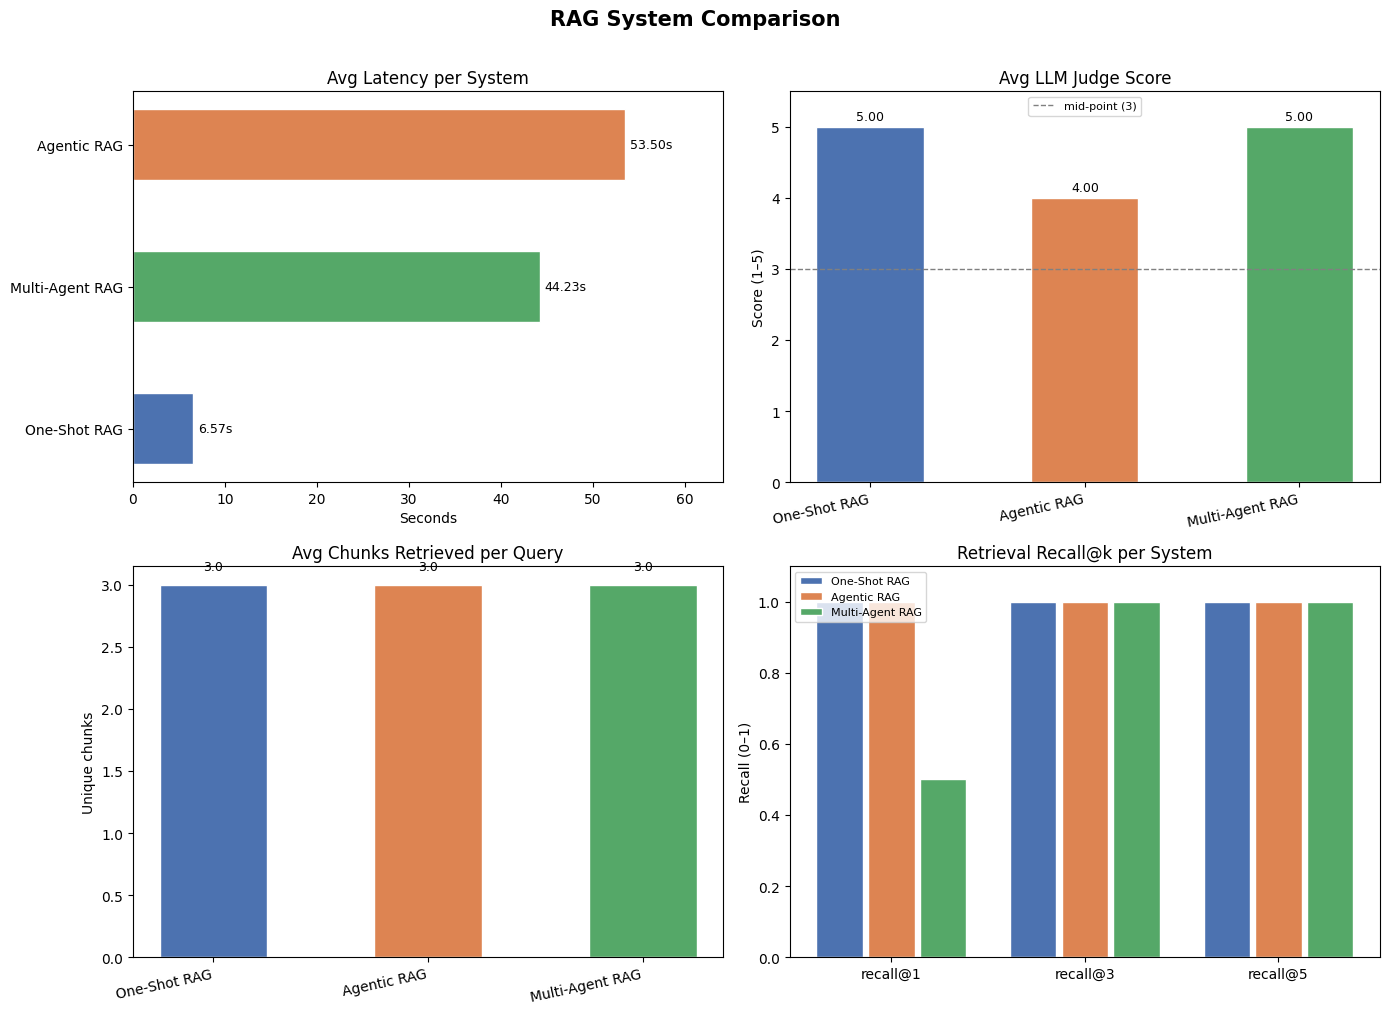

In [91]:
COLORS = {
    "One-Shot RAG":    "#4C72B0",
    "Agentic RAG":     "#DD8452",
    "Multi-Agent RAG": "#55A868",
}

systems   = list(COLORS.keys())
bar_width = 0.25
x         = np.arange(len(systems))

avgs = df_eval.reset_index().groupby("system")[
    df_eval.select_dtypes(include="number").columns
].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("RAG System Comparison", fontsize=15, fontweight="bold", y=1.01)

# ── Helper: add value labels on bars ─────────────────────────────────────────
def _label_bars(ax, bars, fmt="{:.2f}", pad=0.02):
    for bar in bars:
        h = bar.get_height() if bar.get_height() else bar.get_width()
        if bar.get_height() != 0:   # vertical
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + pad,
                fmt.format(bar.get_height()), ha="center", va="bottom", fontsize=9,
            )
        else:                       # horizontal
            ax.text(
                bar.get_width() + pad, bar.get_y() + bar.get_height() / 2,
                fmt.format(bar.get_width()), ha="left", va="center", fontsize=9,
            )

# ── Top-left: avg latency ─────────────────────────────────────────────────────
ax = axes[0, 0]
latencies = [avgs.loc[s, "latency_s"] if s in avgs.index else 0 for s in systems]
sorted_pairs = sorted(zip(latencies, systems), reverse=True)
s_lats, s_sys = zip(*sorted_pairs)
colors_sorted = [COLORS[s] for s in s_sys]
bars = ax.barh(s_sys, s_lats, color=colors_sorted, edgecolor="white", height=0.5)
for bar, val in zip(bars, s_lats):
    ax.text(val + max(s_lats) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}s", va="center", fontsize=9)
ax.set_xlabel("Seconds")
ax.set_title("Avg Latency per System")
ax.set_xlim(0, max(s_lats) * 1.2)
ax.invert_yaxis()

# ── Top-right: avg LLM judge score ───────────────────────────────────────────
ax = axes[0, 1]
scores = [avgs.loc[s, "llm_judge (1-5)"] if s in avgs.index else 0 for s in systems]
bars = ax.bar(systems, scores, color=[COLORS[s] for s in systems], edgecolor="white", width=0.5)
_label_bars(ax, bars, fmt="{:.2f}", pad=0.05)
ax.axhline(3, color="grey", linestyle="--", linewidth=1, label="mid-point (3)")
ax.set_ylim(0, 5.5)
ax.set_ylabel("Score (1–5)")
ax.set_title("Avg LLM Judge Score")
ax.legend(fontsize=8)
ax.set_xticks(range(len(systems)))
ax.set_xticklabels(systems, rotation=12, ha="right")

# ── Bottom-left: avg chunks retrieved ────────────────────────────────────────
ax = axes[1, 0]
chunks = [avgs.loc[s, "chunks_retrieved"] if s in avgs.index else 0 for s in systems]
bars = ax.bar(systems, chunks, color=[COLORS[s] for s in systems], edgecolor="white", width=0.5)
_label_bars(ax, bars, fmt="{:.1f}", pad=0.1)
ax.set_ylabel("Unique chunks")
ax.set_title("Avg Chunks Retrieved per Query")
ax.set_xticks(range(len(systems)))
ax.set_xticklabels(systems, rotation=12, ha="right")

# ── Bottom-right: recall@k OR judge heatmap ───────────────────────────────────
ax = axes[1, 1]
recall_cols = [c for c in df_eval.columns if c.startswith("recall@")]

if recall_cols:
    # Grouped bar chart — one group per k value
    ks = sorted(int(c.split("@")[1]) for c in recall_cols)
    n_k = len(ks)
    width = 0.8 / len(systems)
    for i, sys in enumerate(systems):
        vals = [
            avgs.loc[sys, f"recall@{k}"] if (sys in avgs.index and f"recall@{k}" in avgs.columns) else 0
            for k in ks
        ]
        offsets = np.arange(n_k) + i * width - (len(systems) - 1) * width / 2
        bars = ax.bar(offsets, vals, width=width * 0.9,
                      color=COLORS[sys], label=sys, edgecolor="white")
    ax.set_xticks(np.arange(n_k))
    ax.set_xticklabels([f"recall@{k}" for k in ks])
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Recall (0–1)")
    ax.set_title("Retrieval Recall@k per System")
    ax.legend(fontsize=8)
else:
    # Fallback: per-query LLM judge score heatmap
    pivot = df_eval.reset_index().pivot(index="query", columns="system", values="llm_judge (1-5)")
    pivot = pivot[[s for s in systems if s in pivot.columns]]
    im = ax.imshow(pivot.values, aspect="auto", cmap="YlGn", vmin=1, vmax=5)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=12, ha="right", fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    for r in range(pivot.shape[0]):
        for c in range(pivot.shape[1]):
            val = pivot.values[r, c]
            ax.text(c, r, f"{val:.0f}" if not np.isnan(val) else "—",
                    ha="center", va="center", fontsize=11, fontweight="bold",
                    color="black" if val < 4 else "white")
    fig.colorbar(im, ax=ax, label="Judge score (1–5)")
    ax.set_title("LLM Judge Score per Query & System\n(no recall ground truth)")

plt.tight_layout()
plt.show()
